Sources
https://aboskovic21.github.io/projects/pu_gb.pdf
optuna

In [3]:


import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)
mpl.rcParams['text.usetex'] = False

In [4]:
# Main code voor processen van de data
import uproot
import sklearn
import xgboost
import pathlib
import matplotlib.pyplot as plt
import scienceplots
import numpy as np
from matplotlib.pyplot import figure
import corner

figure(figsize=(8, 6), dpi=80)

# Background
with uproot.open(pathlib.Path(r"C:\Users\apogo\Downloads\Data_Dpluspp7TeV_pT_2_3.root")) as file:
    tree = file['treeMLDplus']
    tree.show()
    branches = tree.keys()
    print(branches)
    training_data_bkg = tree.arrays(branches, library="np")
    training_data_bkg['species'] = np.zeros(len(training_data_bkg['inv_mass']))
    # data_matrix = np.column_stack([data[b][:10000] for b in branches])

    # plt.figure(dpi=300)
    # fig = corner.corner(data_matrix, labels=branches)
    # inv_mass_training = tree.arrays(['inv_mass'],library='np')

# Signal
with uproot.open(pathlib.Path(r"C:\Users\apogo\Downloads\FD_Dpluspp7TeV_pT_2_3 (1).root")) as file:
    tree = file['treeMLDplus']
    tree.show()
    branches = tree.keys()
    print(branches)
    training_data_FD = tree.arrays(branches, library="np")
    training_data_FD['species'] = np.ones(len(training_data_FD['inv_mass']))
    # data_matrix = np.column_stack([data[b][:10000] for b in branches])

    # plt.figure(dpi=300)
    # fig = corner.corner(data_matrix, labels=branches)
    # inv_mass_FD = tree.arrays(['inv_mass'],library='np')


name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
inv_mass             | float                    | AsDtype('>f4')
pt_cand              | float                    | AsDtype('>f4')
d_len                | float                    | AsDtype('>f4')
d_len_xy             | float                    | AsDtype('>f4')
norm_dl_xy           | float                    | AsDtype('>f4')
cos_p                | float                    | AsDtype('>f4')
cos_p_xy             | float                    | AsDtype('>f4')
imp_par_xy           | float                    | AsDtype('>f4')
sig_vert             | float                    | AsDtype('>f4')
max_norm_d0d0exp     | float                    | AsDtype('>f4')
nsigComb_Pi_0        | float                    | AsDtype('>f4')
nsigComb_K_0         | float                    | AsDtype('>f4')
nsigComb_Pi_1        | float                    | AsDtype(

<Figure size 640x480 with 0 Axes>

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb

FD_df = pd.DataFrame(training_data_FD)
kbg_df = pd.DataFrame(training_data_bkg)

full_data = pd.concat([FD_df,kbg_df])

inv_mass = full_data["inv_mass"].values


In [6]:
print(len(training_data_bkg['inv_mass']) / len(training_data_FD['inv_mass']))

810.3201663201663


In [654]:
#x_data = full_data[branches] # is 'cheating'

features = [b for b in branches if b not in ["inv_mass","pt_cand", "species"]]
x_data = full_data[features]
y_data = full_data['species']
print(set(y_data))

# stratify to ensure: fraction signal / background in train is approx. fraction signal / background in test
# Als bijv. x_test[10] wordt geselecteerd, dan is: y_test[10] de label, en m_test[10] de invariant mass van exact hetzelfde event
x_train, x_test, y_train, y_test, m_train, m_test = train_test_split(
    x_data,
    y_data,
    inv_mass,
    test_size=0.2,
    random_state=7,
    stratify=y_data
)

#x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.2, random_state=7)
print(np.unique(y_train, return_counts=True))

# Settings we train the xgbclassifier with, the options we pass to the xgbclassifier are the hyperparameters we want to optimise.
#try np.log
pos_class_weight = (len(training_data_bkg['inv_mass']) / len(training_data_FD['inv_mass']))

model = xgb.XGBClassifier(
    learning_rate=0.05,
    n_estimators=1000,
    objective='binary:logistic',
    reg_alpha=0.5,
    reg_lambda=0.5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    scale_pos_weight=pos_class_weight,
    max_delta_step=1,
    max_depth=6,
    random_state=42
)





{0.0, 1.0}
(array([0., 1.]), array([3741734,    4618]))


In [ ]:
model.fit(x_train, y_train,
    eval_set=[(x_train, y_train), (x_test, y_test)],
    verbose=False
)



AttributeError: `best_iteration` is only defined when early stopping is used.

In [658]:
from sklearn.metrics import ( recall_score, precision_score, 
roc_auc_score, accuracy_score, f1_score, confusion_matrix, classification_report)
# Define a function to evaluate the results
def evaluate_results(y_test, y_predict):
    print('Classification results:')
    f1 = f1_score(y_test, y_predict)
    print("f1: %.2f%%" % (f1 * 100.0)) 
    roc = roc_auc_score(y_test, y_predict)
    print("roc: %.2f%%" % (roc * 100.0)) 
    rec = recall_score(y_test, y_predict, average='binary')
    print("recall: %.2f%%" % (rec * 100.0)) 
    prc = precision_score(y_test, y_predict, average='binary')
    print("precision: %.2f%%" % (prc * 100.0))

# Evaluate the model
predictions = model.predict(x_test)
print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions))
print("\nClassification Report:")
print(classification_report(y_test, predictions))

# Make predictions on the testing set and evaluate the results


y_predict = model.predict(x_test)

y_proba = model.predict_proba(x_test)[:,1]
threshold = 0.65  # experiment with 0.6, 0.65, 0.7
y_pred_thresh = (y_proba >= threshold).astype(int)

evaluate_results(y_test, y_pred_thresh)

Confusion Matrix:
[[918645  16789]
 [   212    942]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99    935434
         1.0       0.05      0.82      0.10      1154

    accuracy                           0.98    936588
   macro avg       0.53      0.90      0.55    936588
weighted avg       1.00      0.98      0.99    936588

Classification results:
f1: 13.29%
roc: 88.42%
recall: 78.08%
precision: 7.26%


In [659]:
import numpy as np

from sklearn.metrics import ( recall_score, precision_score, 
roc_auc_score, accuracy_score, f1_score, confusion_matrix, classification_report)
# predict probabilities
y_proba = model.predict_proba(x_test)[:, 1]

# mogelijke thresholds testen
thresholds = np.linspace(0.1, 0.9, 81)  # van 0.1 tot 0.9 in stappen van 0.01
f1_scores = []

for t in thresholds:
    y_pred_thresh = (y_proba >= t).astype(int)
    f1 = f1_score(y_test, y_pred_thresh)
    f1_scores.append(f1)

# beste threshold vinden
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Beste threshold: {best_threshold:.2f}, F1-score: {best_f1:.4f}")

# evaluatie met de beste threshold
y_pred_best = (y_proba >= best_threshold).astype(int)
evaluate_results(y_test, y_pred_best)


Beste threshold: 0.90, F1-score: 0.2611
Classification results:
f1: 26.11%
roc: 83.19%
recall: 66.81%
precision: 16.23%


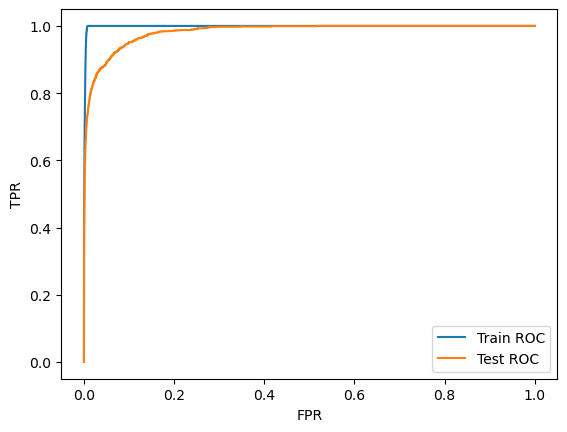

In [660]:
#checking for overfitting with roc

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_train_pred = model.predict_proba(x_train)[:,1]
y_test_pred  = model.predict_proba(x_test)[:,1]

fpr_tr, tpr_tr, _ = roc_curve(y_train, y_train_pred)
fpr_te, tpr_te, _ = roc_curve(y_test,  y_test_pred)

plt.plot(fpr_tr, tpr_tr, label="Train ROC")
plt.plot(fpr_te, tpr_te, label="Test ROC")
plt.legend(); plt.xlabel("FPR"); plt.ylabel("TPR")
plt.show()


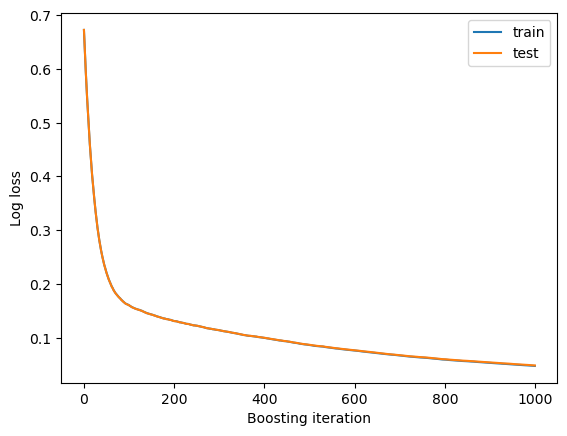

In [ ]:
import matplotlib.pyplot as plt

results = model.evals_result()

plt.plot(results["validation_0"]["logloss"], label="train")
plt.plot(results["validation_1"]["logloss"], label="test")
plt.xlabel("Boosting iteration")
plt.ylabel("Log loss")
plt.legend()
plt.show()


#https://xgboosting.com/xgboost-evals_result-method/


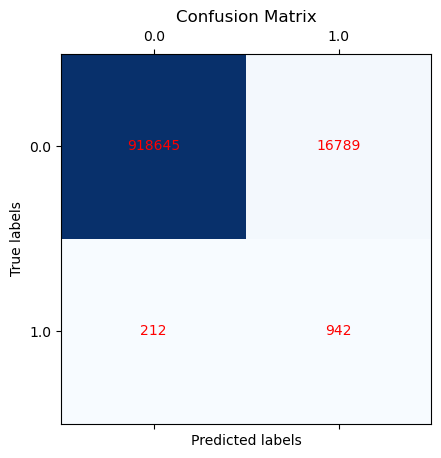

In [681]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_predict)

import numpy as np

labels = np.unique(y_test)

fig, ax = plt.subplots()
im = ax.matshow(cm, cmap=plt.cm.Blues)

# Toon getallen in de cellen
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, f"{cm[i, j]}", ha="center", va="center", color="red")

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()



In [663]:
#Accuracy is geen overfitting-indicator in sterk ongebalanceerde data!!

#demonstrates how to compare training and validation accuracy to detect overfitting:
"""
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_classification

# Generate synthetic binary classification dataset
X, y = make_classification(n_samples=1000, n_classes=2, random_state=42)

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Train XGBoost model
xgb_clf = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_clf.fit(X_train, y_train)

# Predict on training and validation sets
train_preds = xgb_clf.predict(X_train)
val_preds = xgb_clf.predict(X_val)

# Calculate accuracy scores
train_accuracy = accuracy_score(y_train, train_preds)
val_accuracy = accuracy_score(y_val, val_preds)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

# Check for large difference between train and validation accuracy
if train_accuracy - val_accuracy > 0.1:
    print("Warning: The model may be overfitting!")"""

'\nfrom sklearn.model_selection import train_test_split\nfrom xgboost import XGBClassifier\nfrom sklearn.metrics import accuracy_score\nfrom sklearn.datasets import make_classification\n\n# Generate synthetic binary classification dataset\nX, y = make_classification(n_samples=1000, n_classes=2, random_state=42)\n\n# Split data into training and validation sets\nX_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)\n\n# Train XGBoost model\nxgb_clf = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)\nxgb_clf.fit(X_train, y_train)\n\n# Predict on training and validation sets\ntrain_preds = xgb_clf.predict(X_train)\nval_preds = xgb_clf.predict(X_val)\n\n# Calculate accuracy scores\ntrain_accuracy = accuracy_score(y_train, train_preds)\nval_accuracy = accuracy_score(y_val, val_preds)\n\nprint(f"Training Accuracy: {train_accuracy:.4f}")\nprint(f"Validation Accuracy: {val_accuracy:.4f}")\n\n# Check for large difference between train and val

In [664]:
y_score = model.predict_proba(x_test)[:, 1]


In [665]:
import numpy as np

signal_scores = y_score[y_test == 1]
background_scores = y_score[y_test == 0]


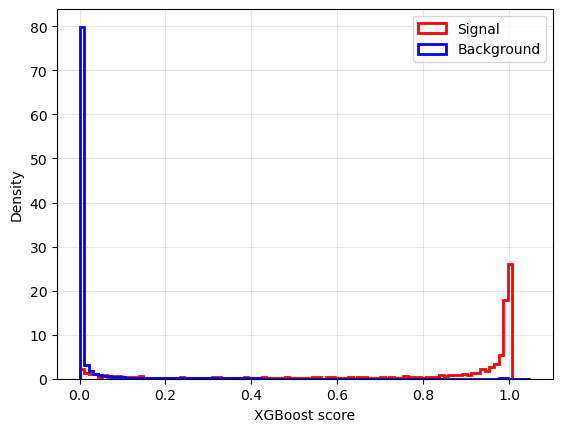

In [666]:
import matplotlib.pyplot as plt
import numpy as np

bins = np.linspace(0, 1.05, 100)

plt.hist(signal_scores, bins=bins, histtype='step',
         density=True, linewidth=2, color='red', label='Signal')

plt.hist(background_scores, bins=bins, histtype='step',
         density=True, linewidth=2, color='blue', label='Background')

plt.xlabel("XGBoost score")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [780]:
score_cut = 0.9
mask = y_score > score_cut

mass_selected = m_test[mask]


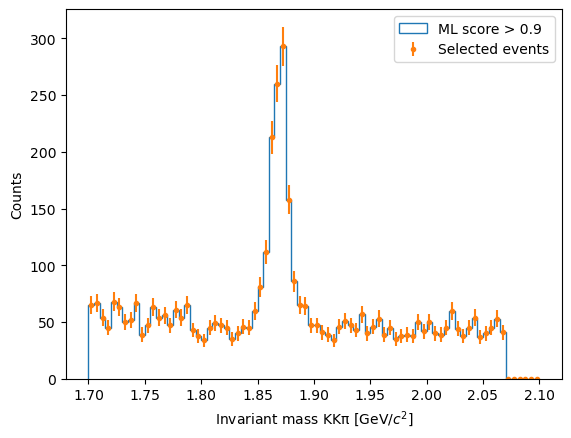

In [781]:
plt.hist(
    mass_selected,
    bins=80,
    range=(1.7, 2.1),
    histtype="step",
    label=f"ML score > {score_cut}"
)

range_mass = (1.7, 2.1)
hist_vals, bin_edges = np.histogram(mass_selected, bins=80, range=range_mass)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
errors = np.sqrt(hist_vals)  # Poisson errors

plt.errorbar(bin_centers, hist_vals, yerr=errors, fmt='.', label='Selected events')
plt.xlabel("Invariant mass KKπ [GeV/$c^2$]")
plt.ylabel("Counts")
plt.legend()
plt.show()


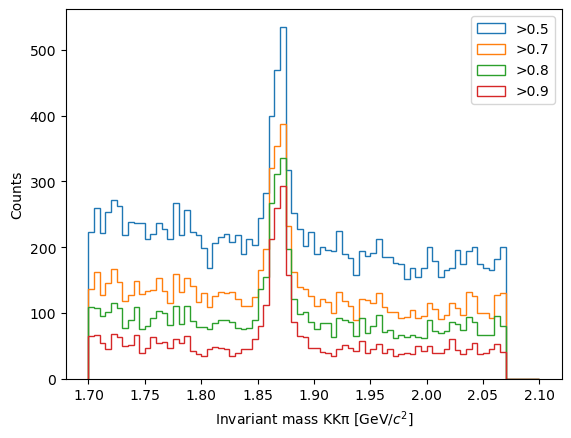

In [787]:
for cut in [0.5, 0.7, 0.8, 0.9]:
    mask = y_score > cut
    plt.hist(
        m_test[mask],
        bins=80,
        range=(1.7,2.1),
        histtype="step",
        label=f">{cut}"
    )

plt.xlabel("Invariant mass KKπ [GeV/$c^2$]")
plt.ylabel("Counts")
plt.legend()
plt.show()


In [783]:
import numpy as np
from scipy.optimize import curve_fit
from scipy.integrate import quad
import matplotlib.pyplot as plt

def exponential(x, a, b, d):
    return a * np.exp(b * x) + d

def gaussian(x, a, mu, sigma):
    return a * np.exp(-(x-mu)**2/(2*sigma**2))

def signal_to_background_from_params(gauss_params, exp_params, k=3):
    a_g, mu_g, sigma_g = gauss_params
    a_e, b_e, d_e = exp_params

    x_min, x_max = mu_g - k*sigma_g, mu_g + k*sigma_g
    S, _ = quad(lambda x: gaussian(x, *gauss_params), x_min, x_max)
    B, _ = quad(lambda x: exponential(x, *exp_params), x_min, x_max)
    S_over_B = S / B
    return S, B, S_over_B

def bump_hunt(candidates, bins=80, signal_window=(1.84, 1.91)):

    # Histogram

    hist, bin_edges = np.histogram(mass_selected, bins=80, range=(np.min(mass_selected), np.max(mass_selected)))
    bin_centers = 0.5*(bin_edges[:-1] + bin_edges[1:])


    # Exclude signal window for background fit
    mask = (bin_centers < signal_window[0]) | (bin_centers > signal_window[1])
    hist_bkg, bins_bkg = hist[mask], bin_centers[mask]

   

    # Fit exponential
    popt_exp, pcov_exp = curve_fit(exponential, bins_bkg, hist_bkg, p0=(max(hist_bkg), -1, min(hist_bkg)))

    # Fit Gaussian + exponential
    def gauss_plus_exp(x, a_g, mu_g, sigma_g):
        return gaussian(x, a_g, mu_g, sigma_g) + exponential(x, *popt_exp)
    

    
    popt_gauss, pcov_gauss = curve_fit(gauss_plus_exp, bin_centers, hist, p0=(max(hist)-min(hist), 1.869, 0.02))
    S, B, S_over_B = signal_to_background_from_params(popt_gauss, popt_exp)
    sigma_params = np.sqrt(np.diag(pcov_gauss))  # [Δa_g, Δmu_g, Δsigma_g]

    mu, sigma = popt_gauss[1] * 1000, popt_gauss[2] * 1000  #MeV/c2
    dmu, dsigma = sigma_params[1] * 1000, sigma_params[2] * 1000  #MeV/c2

    # Plot
    x_fit = np.linspace(1.7, 2.1, 500)
    plt.errorbar(bin_centers, hist, yerr=np.sqrt(hist), fmt='.', label='Data')
    plt.plot(x_fit, gauss_plus_exp(x_fit, *popt_gauss), label='Gaussian + Exp fit', color='green')
    plt.plot(x_fit, exponential(x_fit, *popt_exp), '--', label='Background', color='red')
   # plt.plot(x_fit, gaussian(x_fit, *popt_gauss), ':', label='Gaussian', color='blue')
    plt.text(1.91, max(hist)*0.55,
          f"μ = {mu:.3f} ± {dmu:.3f} MeV/c²\n"
          f"σ = {sigma:.3f} ± {dsigma:.3f} MeV/c²\n"
          f"S = {S:.0f} ± {np.sqrt(S):.0f}\n"
          f"S/B (3σ) = {S_over_B:.2f}",
          bbox=dict(facecolor='white', alpha=0.7))

    plt.xlabel('$M$(KKπ) [GeV/c²]')
    plt.ylabel('Counts')
    plt.legend()
    plt.show()

    # Compute S/B
    

    return popt_exp, popt_gauss, S, B, S_over_B



print("Masked bins outside signal window:")
for x, m in zip(bin_centers, mask):
    if m:
        print(f"{x:.3f}")




Masked bins outside signal window:


In [784]:
print("Aantal events in mass_selected:", len(mass_selected))
print("Min mass:", np.min(mass_selected))
print("Max mass:", np.max(mass_selected))
print("Enkele eerste 10 masses:", mass_selected[:10])


Aantal events in mass_selected: 4751
Min mass: 1.6696726
Max mass: 2.0695794
Enkele eerste 10 masses: [1.8909757 1.859306  1.7876579 1.7786909 1.9745942 1.901857  1.8146254
 1.68782   1.8792375 2.0264022]


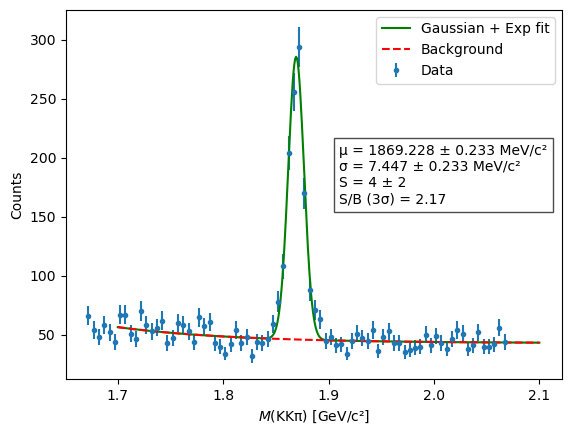

Significance: 1.7475893180954323
S/B: 2.1710132450569444


In [785]:
popt_exp, popt_gauss, S, B, S_over_B = bump_hunt(
    mass_selected, 
    bins=80, 
    signal_window=(1.84, 1.91)
)

significance = S / np.sqrt(S + B)
print("Significance:", significance)
print("S/B:",S_over_B)



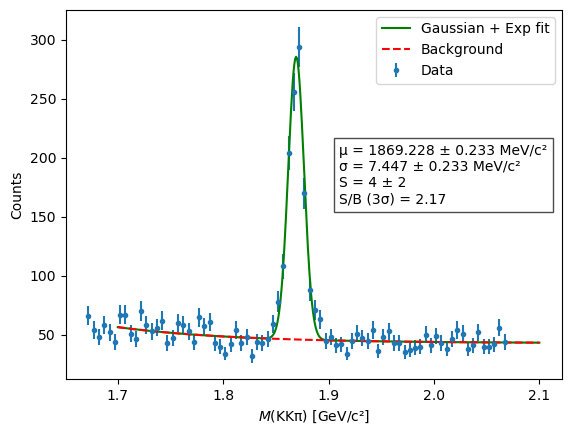

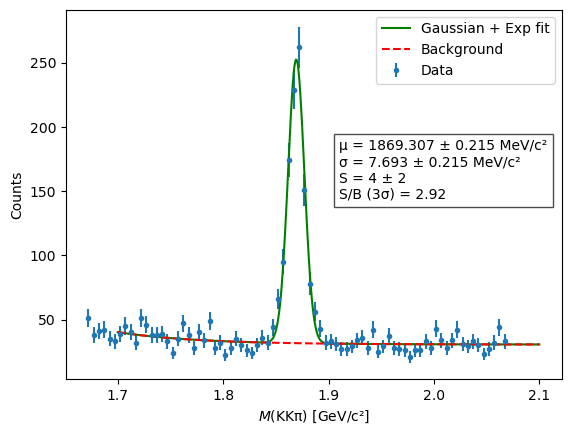

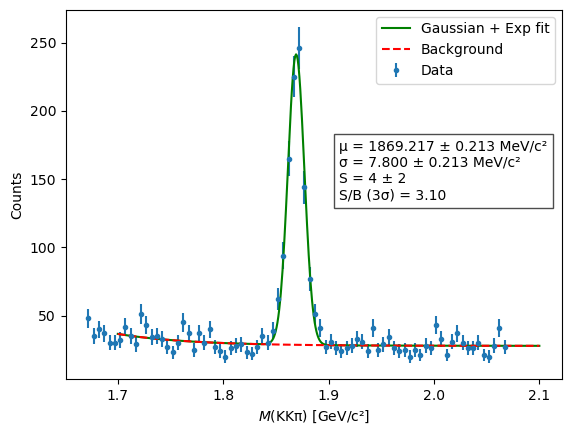

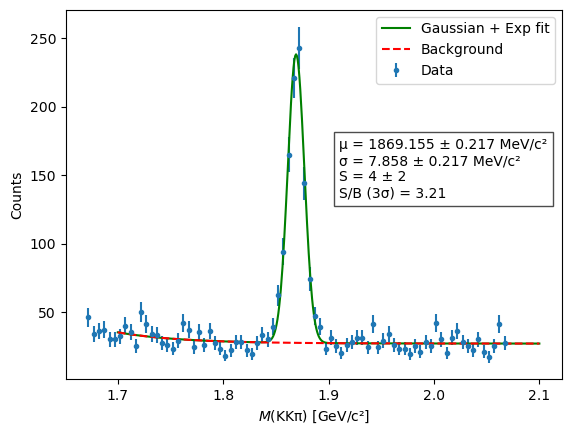

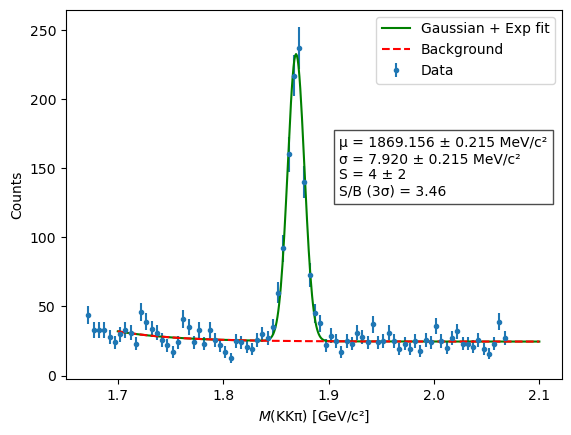

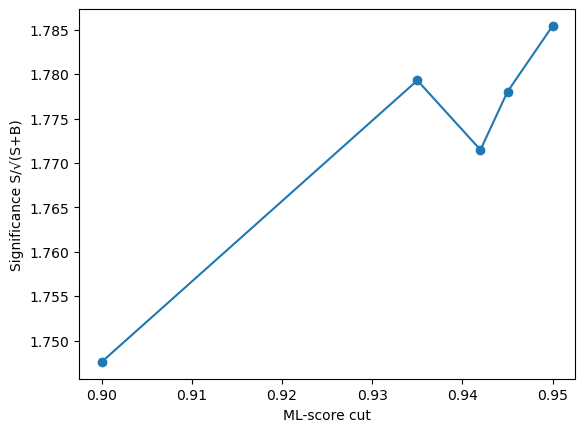

In [786]:
cuts = [0.9, 0.935, 0.942, 0.945, 0.95]
significances = []

for cut in cuts:
    mask = y_score > cut
    mass_selected = m_test[mask]
    _, _, S, B, _ = bump_hunt(mass_selected)
    sig = S / np.sqrt(S+B)
    significances.append(sig)

plt.plot(cuts, significances, marker='o')
plt.xlabel("ML-score cut")
plt.ylabel("Significance S/√(S+B)")
plt.show()
